#  Car insurance Claims Fraud Detection

In [57]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, accuracy_score,recall_score, precision_score, f1_score)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency
import pickle, os

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,'axes.titlesize': 13,'axes.titleweight': 'bold','axes.labelsize':11,'xtick.labelsize':  9,'ytick.labelsize':  9,'legend.fontsize':  9,})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## EPIC 2 — Data Collection & Preparation

### Activity 1.1 — Collect Dataset

In [58]:
# Load dataset
df = pd.read_csv('carclaims.csv')
print('Original shape:', df.shape)
df.head()

Original shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


### Activity 1.2 — Data Preparation

In [59]:
# Step 1: Drop irrelevant columns

DROP_COLS = ['PolicyNumber', 'RepNumber','NumberOfCars', 'BasePolicy','Make', 'AgeOfPolicyHolder','Month', 'DayOfWeek', 'WeekOfMonth','VehicleCategory', 'DayOfWeekClaimed','MonthClaimed', 'Year', 'WeekOfMonthClaimed','WitnessPresent']

DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=DROP_COLS)
print(f'Dropped {len(DROP_COLS)} columns. New shape:', df.shape)
print('Remaining columns:', df.columns.tolist())

Dropped 15 columns. New shape: (15420, 18)
Remaining columns: ['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehiclePrice', 'Deductible', 'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments', 'AddressChange-Claim', 'FraudFound']


In [60]:
# Step 2: Drop invalid ages
df = df[df['Age'] != 0]

# Step 3: Encode binary target
df['FraudFound'] = df['FraudFound'].map({'No': 0, 'Yes': 1})
assert df['FraudFound'].isna().sum() == 0, 'Unexpected values in FraudFound!'

print('After basic cleaning:', df.shape)

After basic cleaning: (15100, 18)


In [61]:
# Step 4: Fill Missing Values
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values remaining:', df.isna().sum().sum())

Missing values remaining: 0


Shape before outlier removal: (15100, 18)


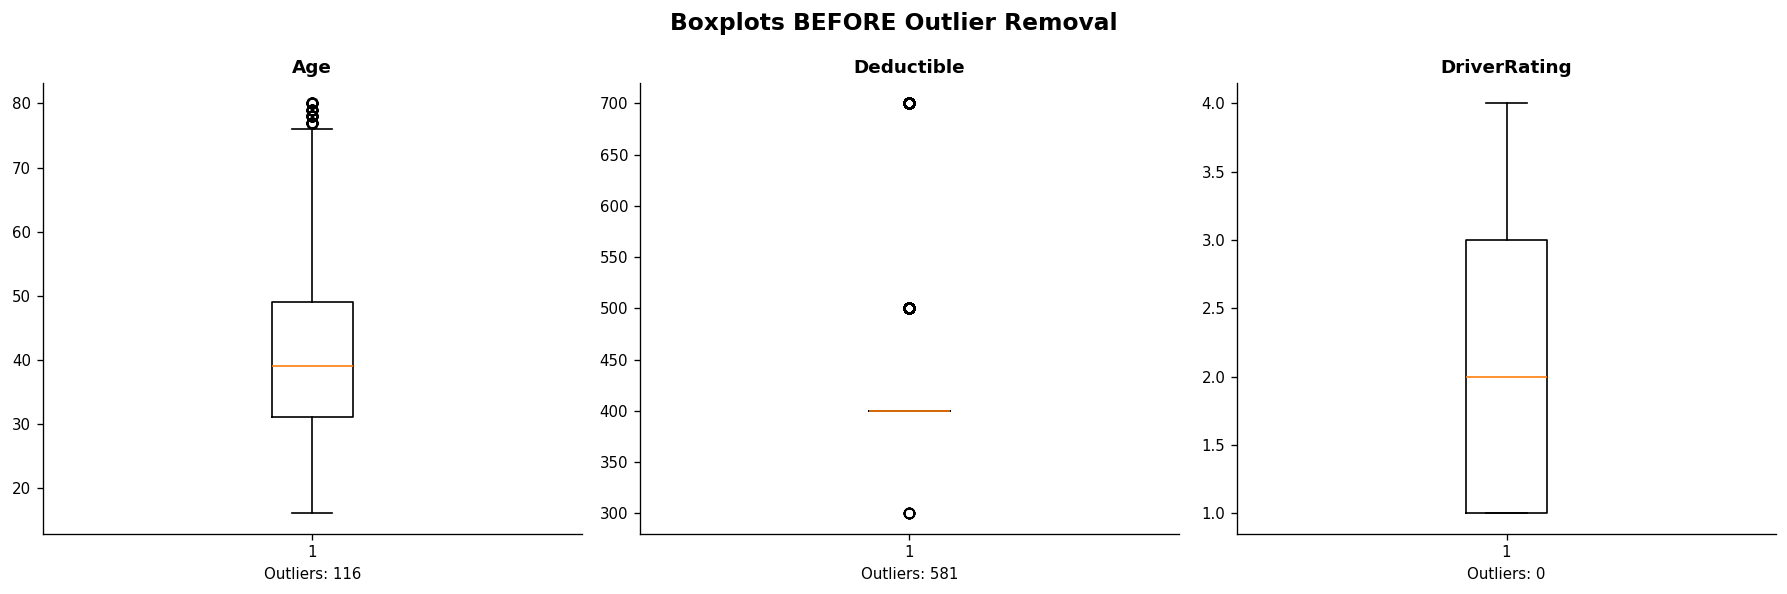

In [62]:
# Step 5: Outlier Detection & Removal (IQR Method)

numeric_cols = [c for c in ['Age', 'Deductible', 'DriverRating'] if c in df.columns]

print('Shape before outlier removal:', df.shape)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
fig.suptitle('Boxplots BEFORE Outlier Removal', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].boxplot(data)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(f'Outliers: {n_out}', fontsize=9)

plt.tight_layout()
plt.show()

Age: removed 116 outliers | bounds [4.00, 76.00]
Deductible: removed 576 outliers | bounds [400.00, 400.00]
DriverRating: removed 0 outliers | bounds [-2.00, 6.00]

Shape after outlier removal: (14408, 18)


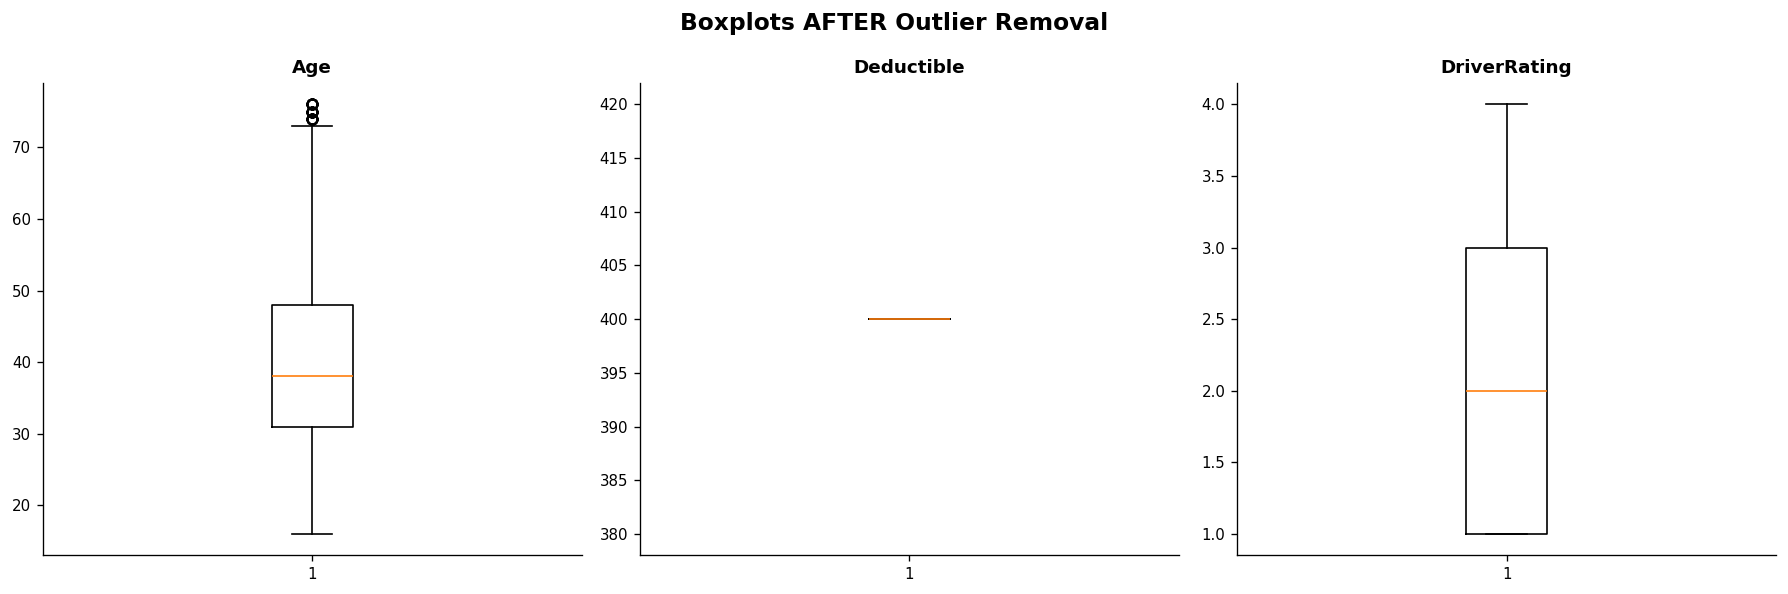

In [63]:
# Remove Outliers
df_clean = df.copy()

for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    print(f'{col}: removed {before - len(df_clean)} outliers | bounds [{lower:.2f}, {upper:.2f}]')

print('\nShape after outlier removal:', df_clean.shape)

# Boxplots AFTER
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
fig.suptitle('Boxplots AFTER Outlier Removal', fontsize=14, fontweight='bold')
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col, fontsize=11)
plt.tight_layout()
plt.show()

df = df_clean.copy()

##  EPIC 3 — Exploratory Data Analysis

### Activity 1.1 — Descriptive Statistical Analysis

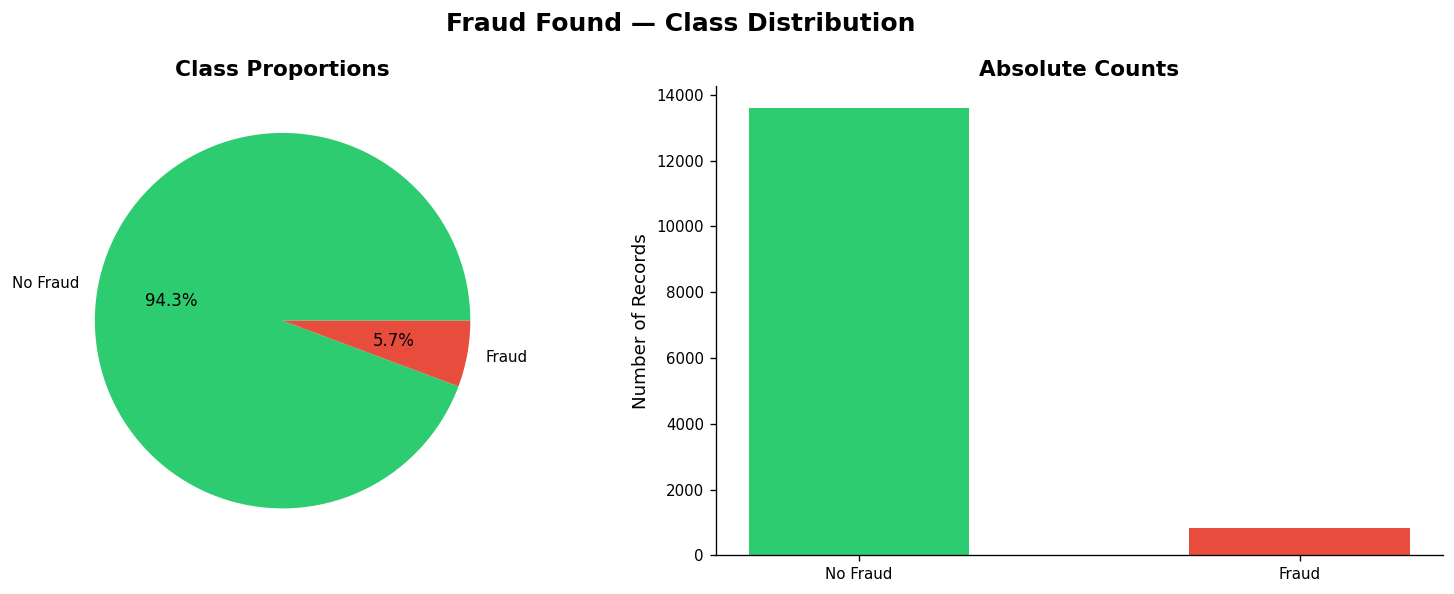

Class distribution (%):
 FraudFound
0    94.308717
1     5.691283
Name: proportion, dtype: float64


In [64]:
# Target distribution
fraud_counts = df['FraudFound'].value_counts()
fraud_pct= df['FraudFound'].value_counts(normalize=True) * 100
labels= ['No Fraud', 'Fraud']

FRAUD_COLORS = ['#2ECC71', '#E74C3C']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fraud Found — Class Distribution', fontsize=15, fontweight='bold')

ax1.pie(fraud_counts, labels=labels, autopct='%1.1f%%', colors=FRAUD_COLORS)
ax1.set_title('Class Proportions')

ax2.bar(labels, fraud_counts.values, color=FRAUD_COLORS, width=0.5)
ax2.set_title('Absolute Counts')
ax2.set_ylabel('Number of Records')

plt.tight_layout()
plt.show()
print('Class distribution (%):\n', fraud_pct)

In [65]:
# Chi-Square test for categorical features

cat_cols = ['AccidentArea', 'PolicyType', 'Fault', 'PoliceReportFiled']
cat_cols = [c for c in cat_cols if c in df.columns]

print(f'{"Feature":<25} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 65)

for col in cat_cols:
    table = pd.crosstab(df[col], df['FraudFound'])
    chi2, p, _, _ = chi2_contingency(table)
    significant   = 'Yes' if p < 0.05 else 'No'
    print(f'{col:<25} {chi2:>10.2f} {p:>12.4f} {significant:>14}')

Feature                         Chi2      p-value   Significant?
-----------------------------------------------------------------
AccidentArea                   22.75       0.0000            Yes
PolicyType                    382.20       0.0000            Yes
Fault                         326.10       0.0000            Yes
PoliceReportFiled               3.27       0.0704             No


### Activity 1.2 — Visual Analysis

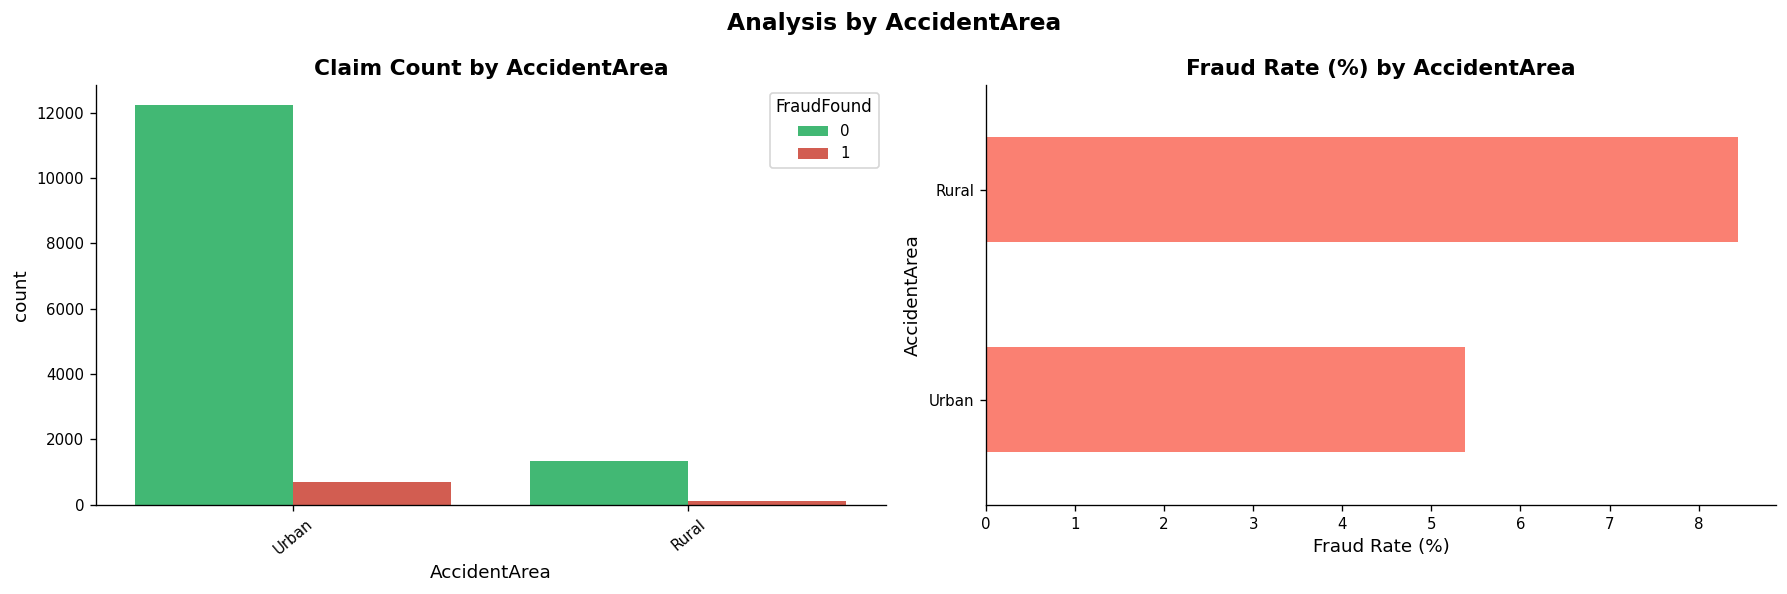

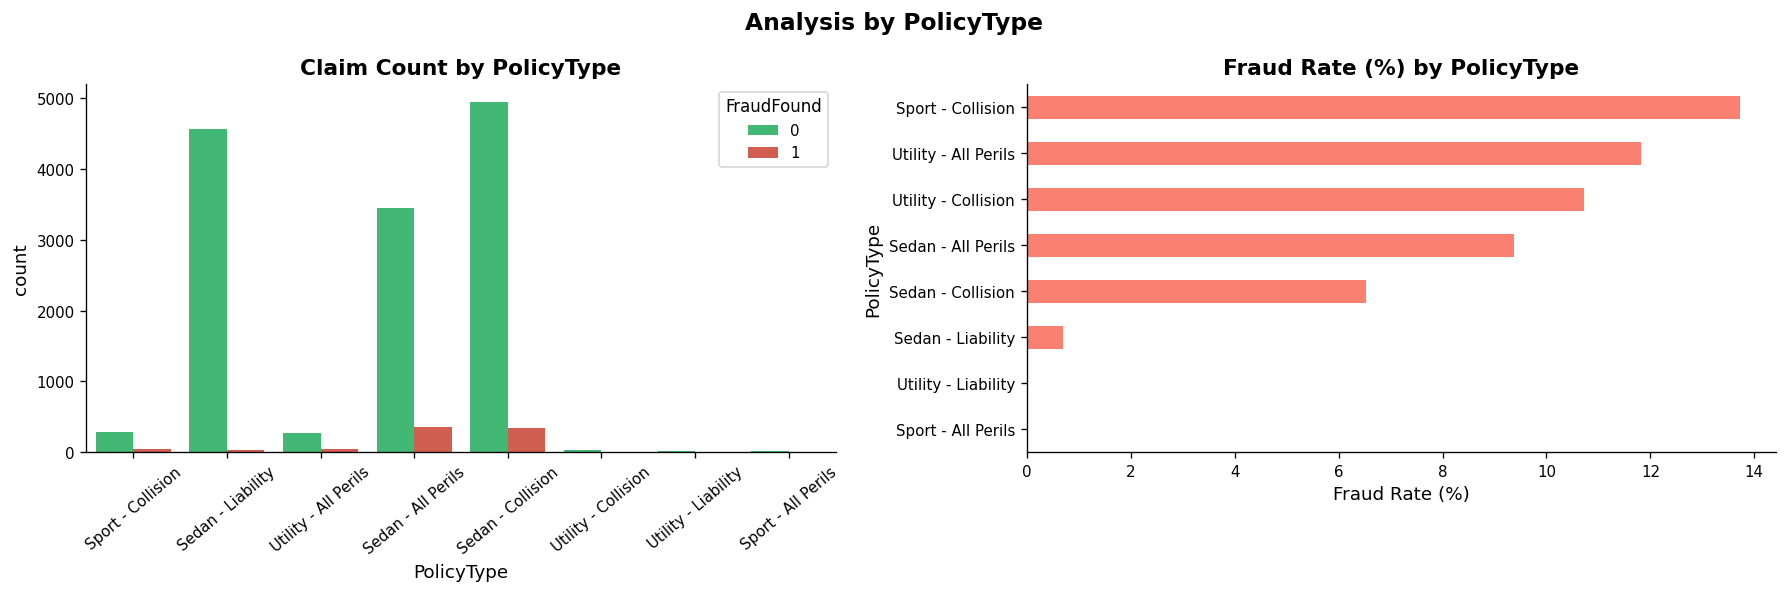

In [66]:
# ── Categorical feature analysis ─────────────────────────────────

categorical_cols = ['AccidentArea', 'PolicyType']
categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Analysis by {col}', fontsize=14, fontweight='bold')

    sns.countplot(x=col, hue='FraudFound', data=df, ax=ax1, palette=FRAUD_COLORS)
    ax1.set_title(f'Claim Count by {col}')
    ax1.tick_params(axis='x', rotation=40)

    fraud_rate = df.groupby(col)['FraudFound'].mean() * 100
    fraud_rate.sort_values().plot(kind='barh', ax=ax2, color='salmon')
    ax2.set_title(f'Fraud Rate (%) by {col}')
    ax2.set_xlabel('Fraud Rate (%)')

    plt.tight_layout()
    plt.show()

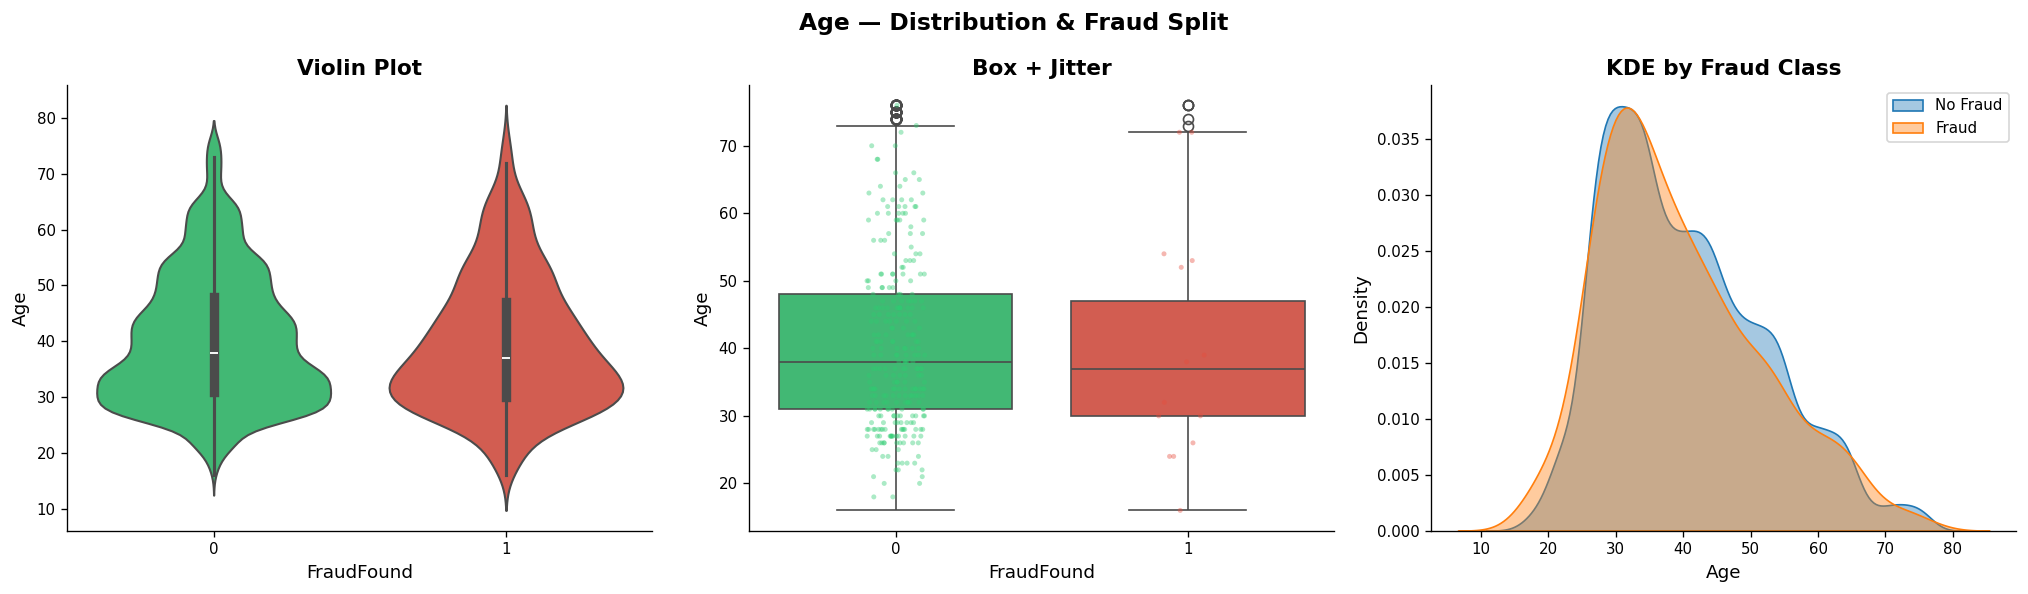

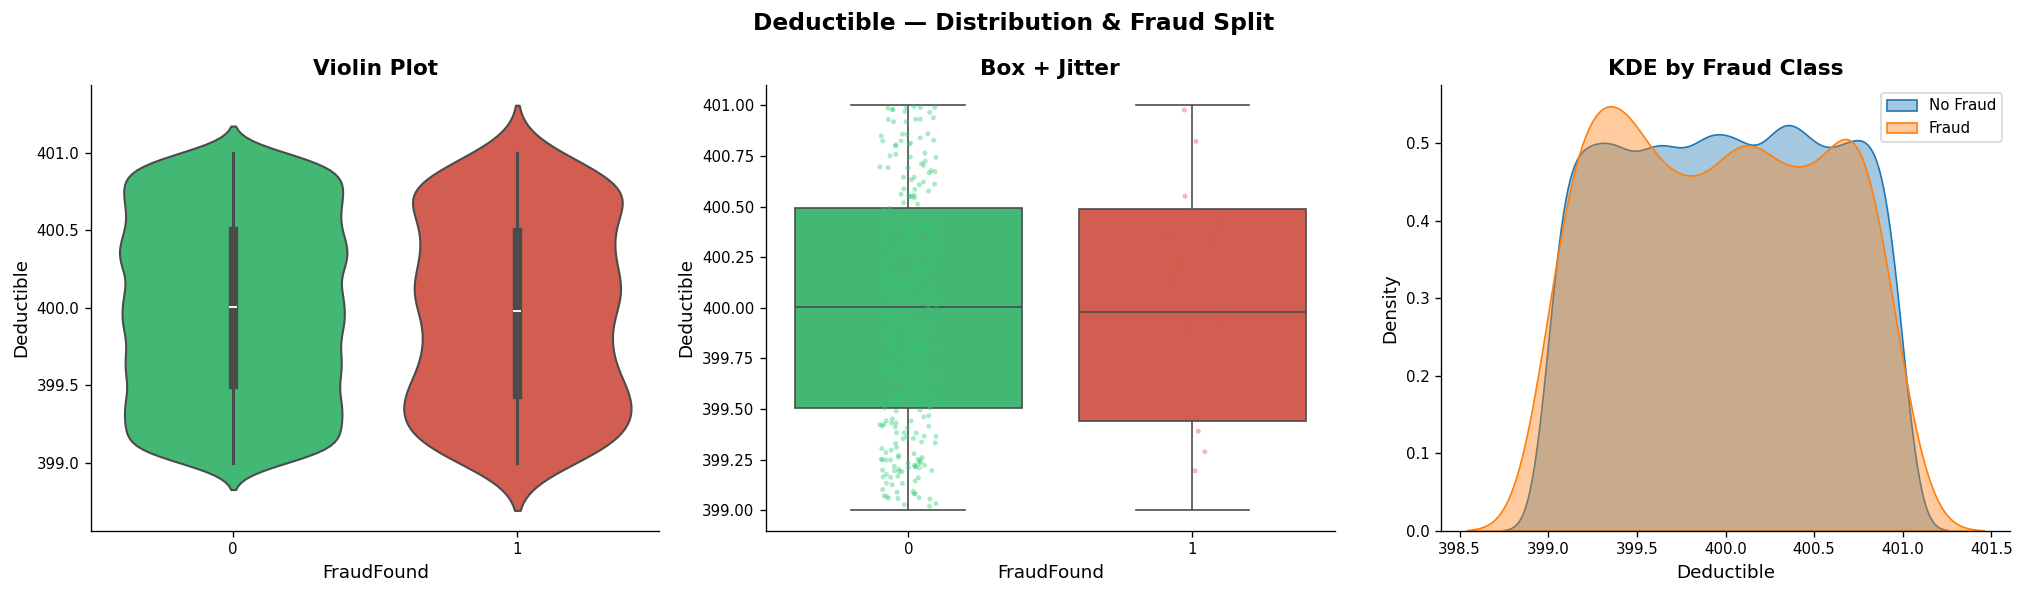

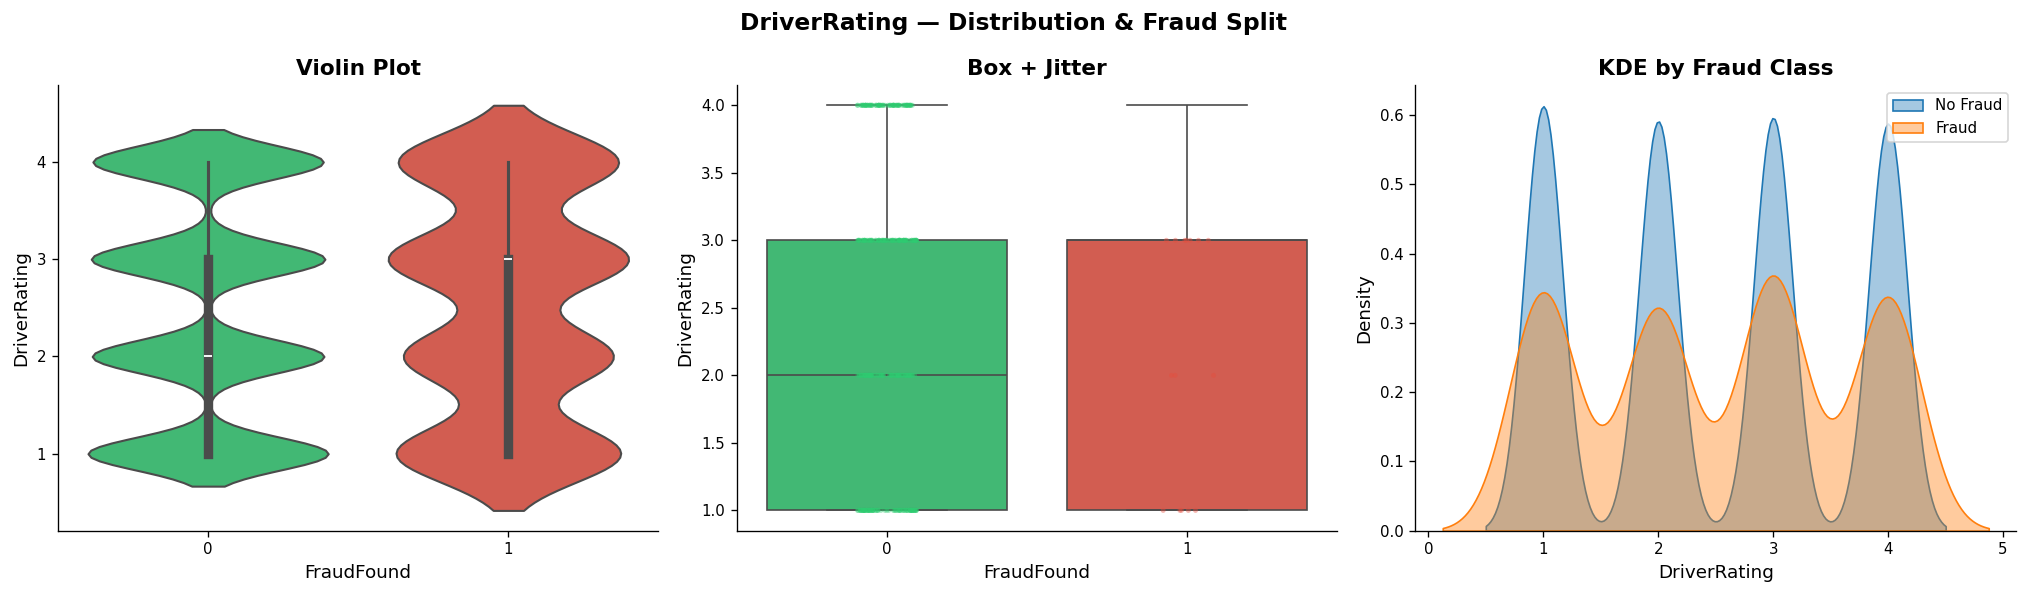

In [67]:
# Numeric feature distributions
num_plot_cols = [c for c in ['Age', 'Deductible', 'DriverRating'] if c in df.columns]

for col in num_plot_cols:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'{col} — Distribution & Fraud Split', fontsize=14, fontweight='bold')

    if col == 'Deductible':
        plot_df = df.copy()
        plot_df[col] = df[col] + np.random.uniform(-1, 1, size=len(df))
    else:
        plot_df = df

    sns.violinplot(x='FraudFound', y=col, data=plot_df, ax=ax1, palette=FRAUD_COLORS)
    ax1.set_title('Violin Plot')

    sns.boxplot(x='FraudFound', y=col, data=plot_df, ax=ax2, palette=FRAUD_COLORS)
    sns.stripplot(x='FraudFound', y=col,
                  data=plot_df.sample(min(300, len(df))),
                  ax=ax2, palette=FRAUD_COLORS, alpha=0.4, size=3)
    ax2.set_title('Box + Jitter')

    for val, label in zip([0, 1], ['No Fraud', 'Fraud']):
        sns.kdeplot(plot_df[plot_df['FraudFound'] == val][col].dropna(),
                    ax=ax3, fill=True, alpha=0.4, label=label)
    ax3.set_title('KDE by Fraud Class')
    ax3.legend()

    plt.tight_layout()
    plt.show()

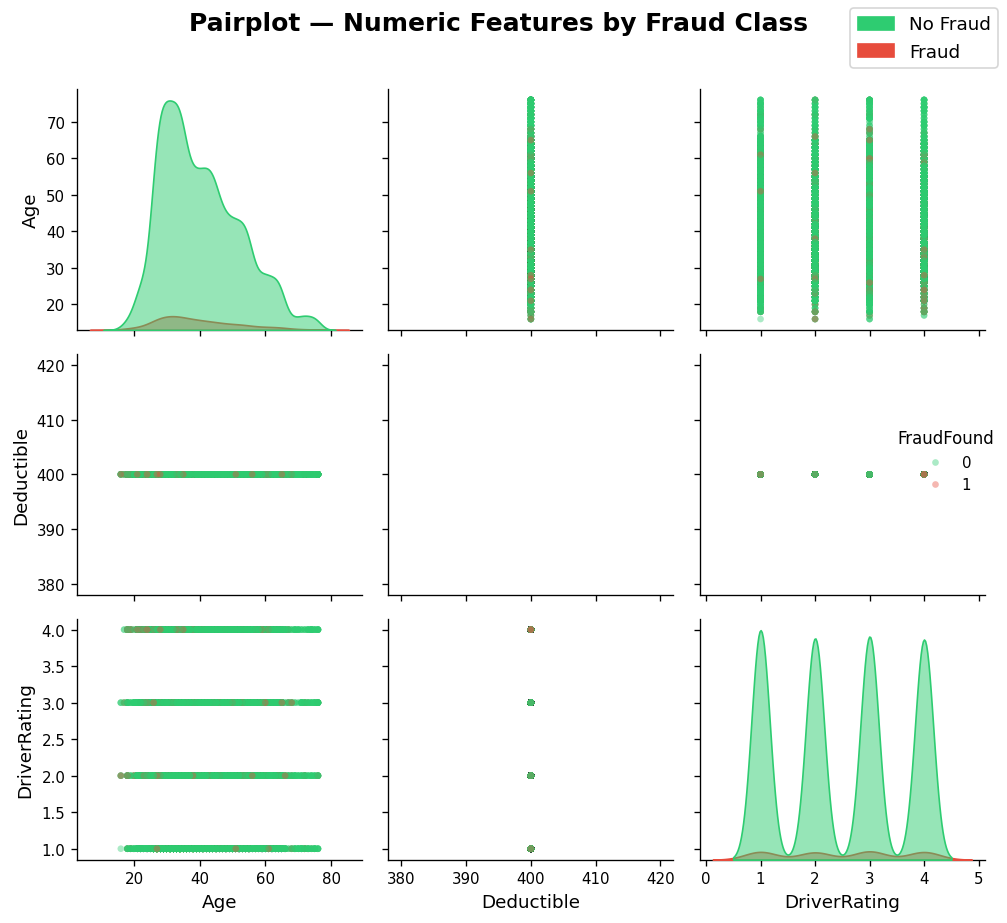

In [68]:
# Multivariate Pairplot
pair_cols = [c for c in ['Age', 'Deductible', 'DriverRating', 'FraudFound'] if c in df.columns]

g = sns.pairplot(df[pair_cols], hue='FraudFound',
    palette={0:'#2ECC71', 1:'#E74C3C'},
    diag_kind='kde',
    plot_kws=dict(alpha=0.4, edgecolor='none', s=16),
    diag_kws=dict(fill=True, alpha=0.5))
g.figure.suptitle('Pairplot — Numeric Features by Fraud Class',
    fontsize=15, fontweight='bold', y=1.02)
handles = [mpatches.Patch(color='#2ECC71', label='No Fraud'),
           mpatches.Patch(color='#E74C3C', label='Fraud')]
g.figure.legend(handles=handles, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

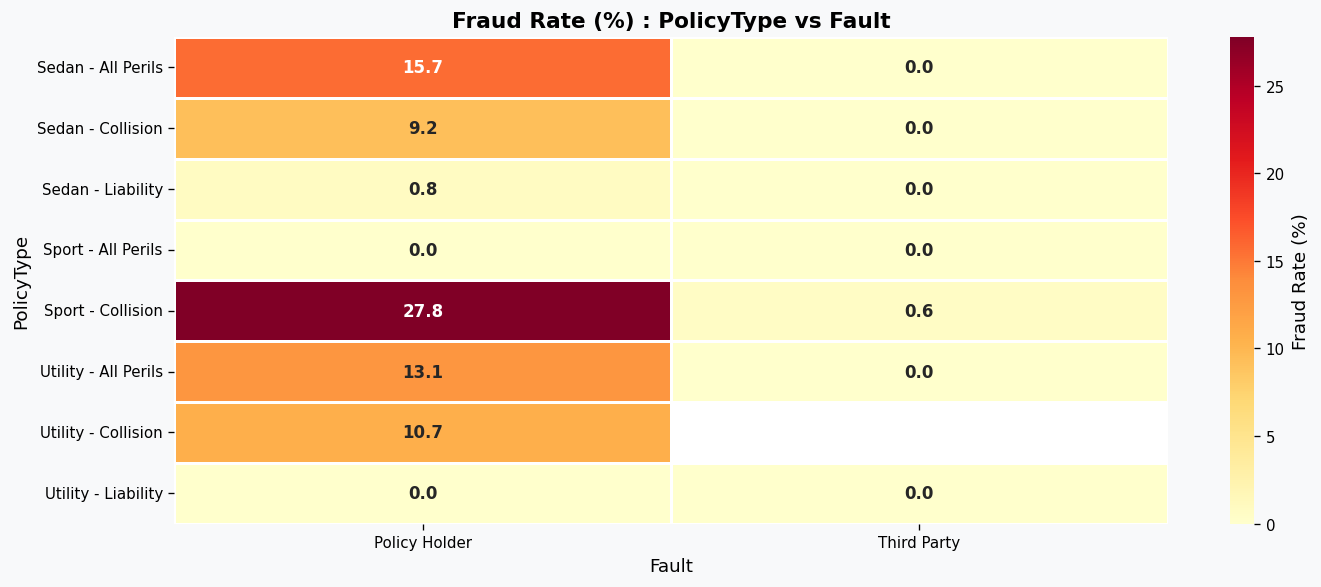

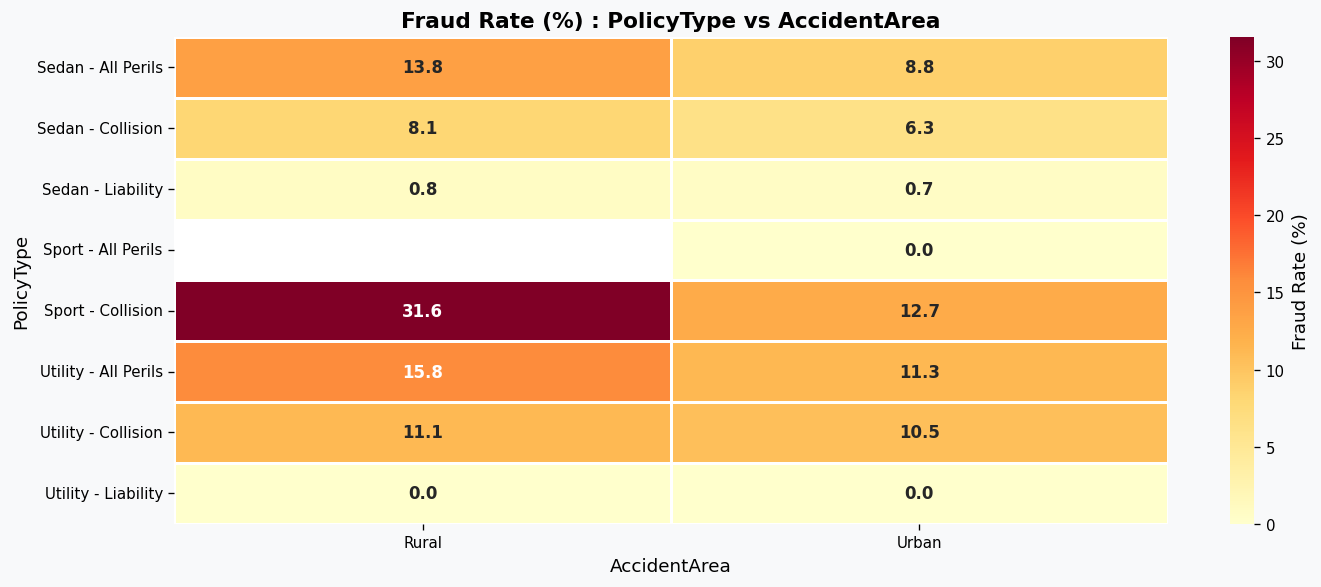

In [69]:
# Cross-feature Fraud Rate Heatmap
for col_x, col_y in [('PolicyType', 'Fault'), ('PolicyType', 'AccidentArea')]:
    if col_x not in df.columns or col_y not in df.columns:
        continue
    pivot = df.pivot_table(
        values='FraudFound', index=col_x, columns=col_y, aggfunc='mean') * 100
    fig, ax = plt.subplots(figsize=(12, 5), facecolor='#F8F9FA')
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.8, linecolor='white', ax=ax,
                annot_kws=dict(size=10, fontweight='bold'),
                cbar_kws=dict(label='Fraud Rate (%)'))
    ax.set_title(f'Fraud Rate (%) : {col_x} vs {col_y}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

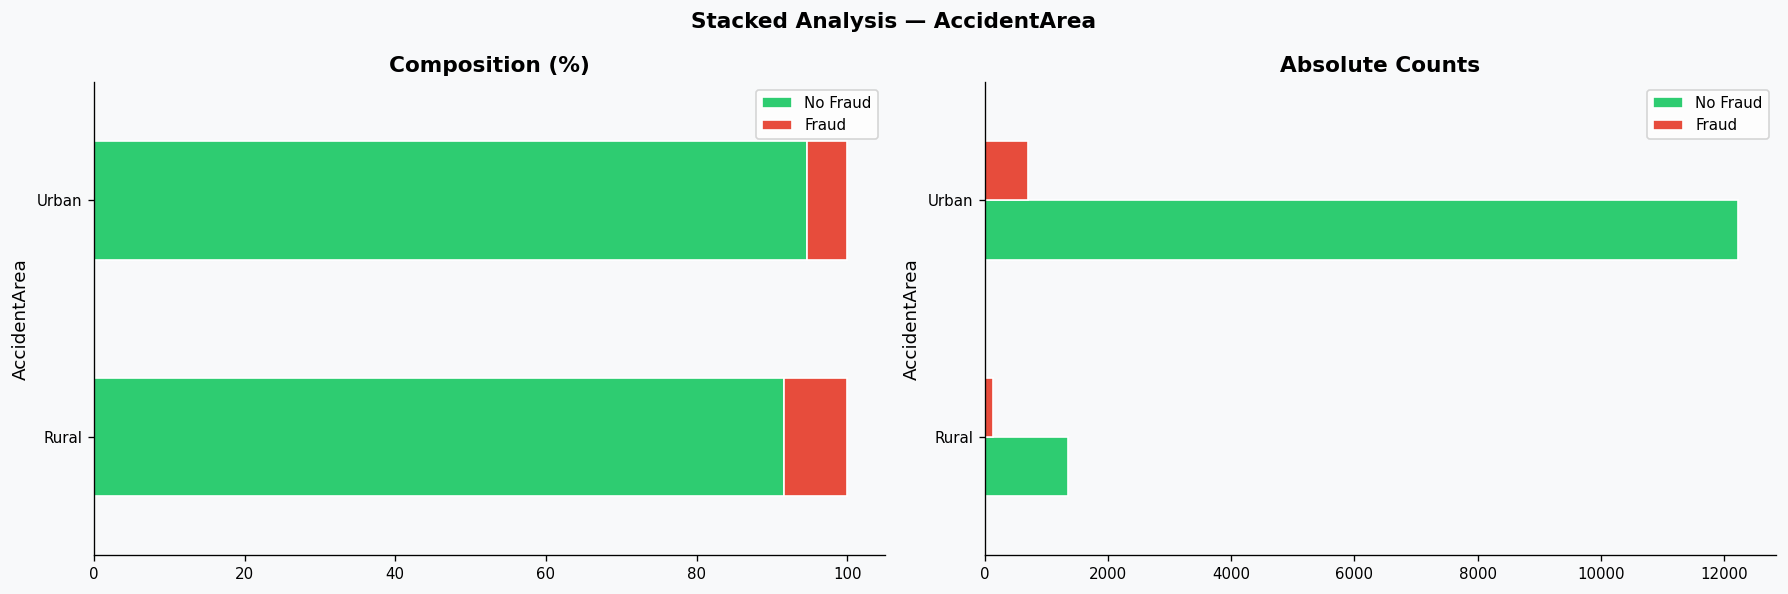

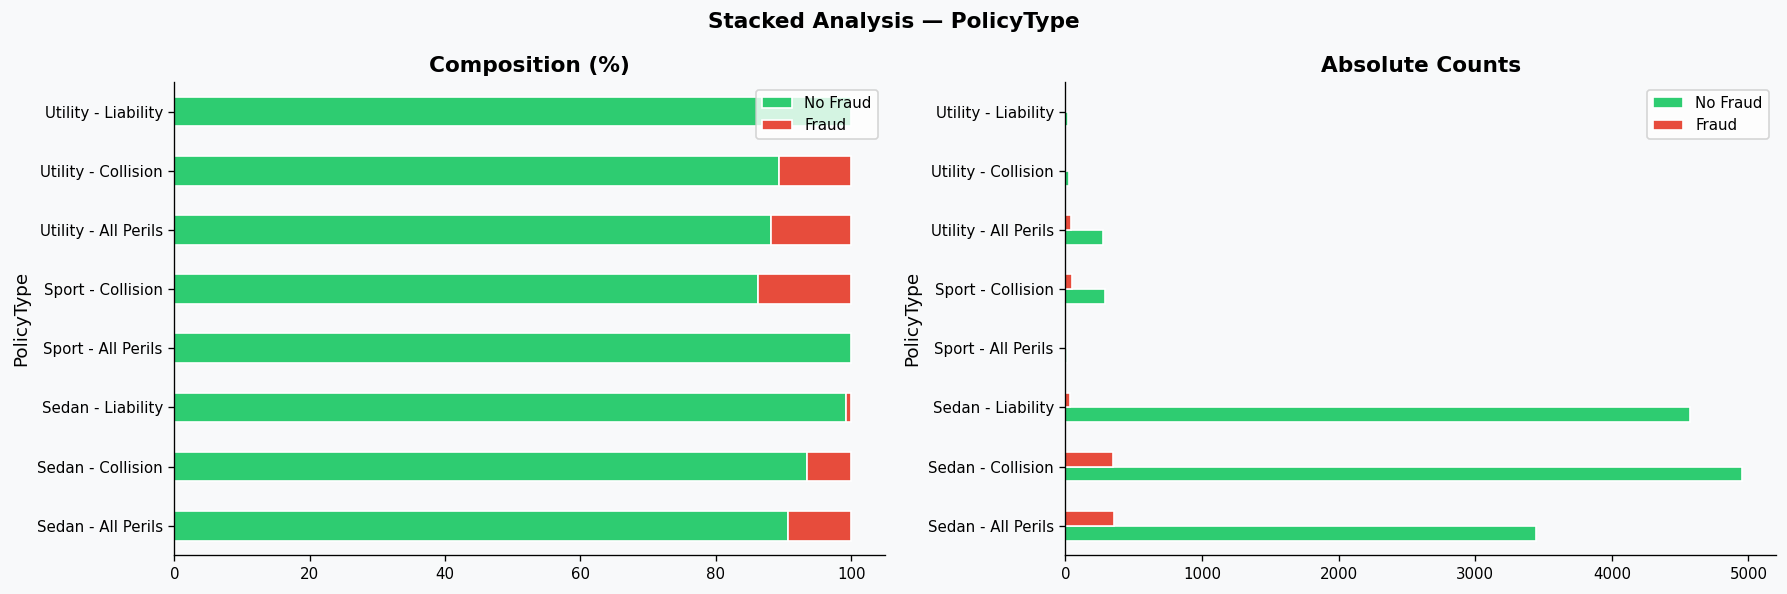

In [70]:
# Stacked Bar Analysis
for col in ['AccidentArea', 'PolicyType']:
    if col not in df.columns:
        continue
    grp = df.groupby([col, 'FraudFound']).size().unstack(fill_value=0)
    grp.columns = ['No Fraud', 'Fraud']
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#F8F9FA')
    fig.suptitle(f'Stacked Analysis — {col}', fontsize=13, fontweight='bold')

    grp_pct.plot(kind='barh', stacked=True,  color=FRAUD_COLORS,
                 edgecolor='white', ax=axes[0])
    axes[0].set_title('Composition (%)'); axes[0].set_facecolor('#F8F9FA')

    grp.plot(kind='barh', stacked=False, color=FRAUD_COLORS,
             edgecolor='white', ax=axes[1])
    axes[1].set_title('Absolute Counts'); axes[1].set_facecolor('#F8F9FA')

    plt.tight_layout()
    plt.show()

## Feature Engineering & Encoding

In [71]:
# Step 6: Encoding categorical features


df['PoliceReportFiled'] = df['PoliceReportFiled'].map({'No': 0, 'Yes': 1})
df['Fault']= df['Fault'].map({'Policy Holder': 0, 'Third Party': 1})

# Ordinal encoding
ord_cols_categories = {'Days:Policy-Accident': ['none','1 to 7','8 to 15','15 to 30','more than 30'],'Days:Policy-Claim':['none','1 to 7','8 to 15','15 to 30','more than 30'],'PastNumberOfClaims':['none','1','2 to 4','more than 4'],'NumberOfSuppliments':['none','1 to 2','3 to 5','more than 5'],'AgeOfVehicle':['new','2 years','3 years','4 years','5 years','6 years','7 years','more than 7'],'VehiclePrice':['less than 20,000','20,000 to 29,000','30,000 to 39,000','40,000 to 59,000','60,000 to 69,000','more than 69,000'],'AddressChange-Claim':['no change','under 6 months','1 year','2 to 3 years','4 to 8 years'],}
for col, categories in ord_cols_categories.items():
    if col in df.columns:
        df[col] = pd.Categorical(df[col], categories=categories, ordered=True).codes

# One-hot encode remaining nominal columns
nominal_cols = ['AccidentArea', 'Sex', 'MaritalStatus', 'PolicyType', 'AgentType']
nominal_cols = [c for c in nominal_cols if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Bool into int
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

df = df.drop_duplicates()
print('Shape after encoding:', df.shape)

Shape after encoding: (13831, 26)


In [72]:
# Step 7: Feature Selection
target   = df['FraudFound']
features = df.drop(columns=['FraudFound'])

# Drop near-zero variance
selector = VarianceThreshold(threshold=0.01)
selector.fit(features)
low_var_cols = features.columns[~selector.get_support()].tolist()
print(f'Low variance columns dropped ({len(low_var_cols)}): {low_var_cols}')
features = features.drop(columns=low_var_cols)

# Drop highly correlated (|r| > 0.95)
corr_matrix = features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.95)]
print(f'Highly correlated columns dropped ({len(high_corr_cols)}): {high_corr_cols}')
features = features.drop(columns=high_corr_cols)

print('\nFinal feature count:', features.shape[1])

Low variance columns dropped (6): ['Deductible', 'Days:Policy-Claim', 'MaritalStatus_Widow', 'PolicyType_Sport - All Perils', 'PolicyType_Utility - Collision', 'PolicyType_Utility - Liability']
Highly correlated columns dropped (1): ['MaritalStatus_Single']

Final feature count: 18


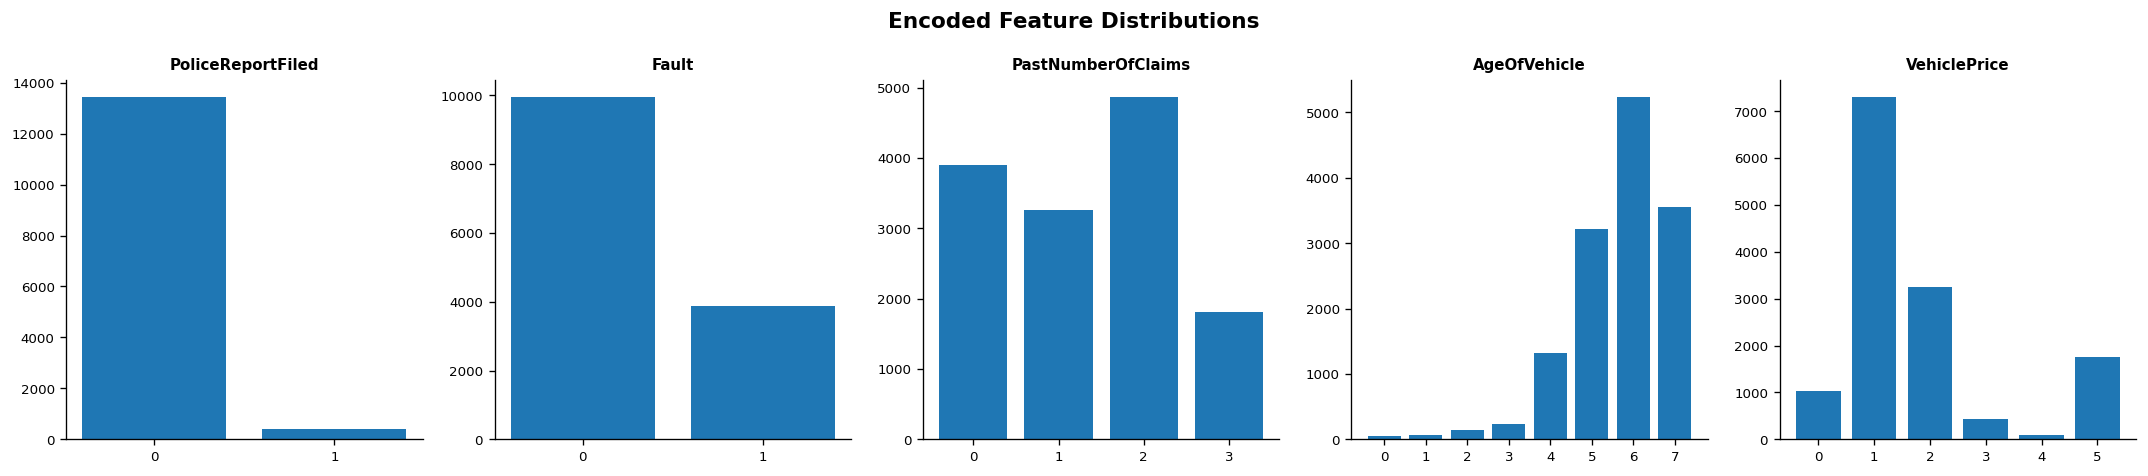

In [73]:
# Encoded Feature Distribution Visualisation
sample_enc = [c for c in ['PoliceReportFiled', 'Fault','PastNumberOfClaims', 'AgeOfVehicle', 'VehiclePrice'] if c in features.columns]

fig, axes = plt.subplots(1, len(sample_enc), figsize=(18, 4))
fig.suptitle('Encoded Feature Distributions', fontsize=13, fontweight='bold')

for i, col in enumerate(sample_enc):
    vc = features[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

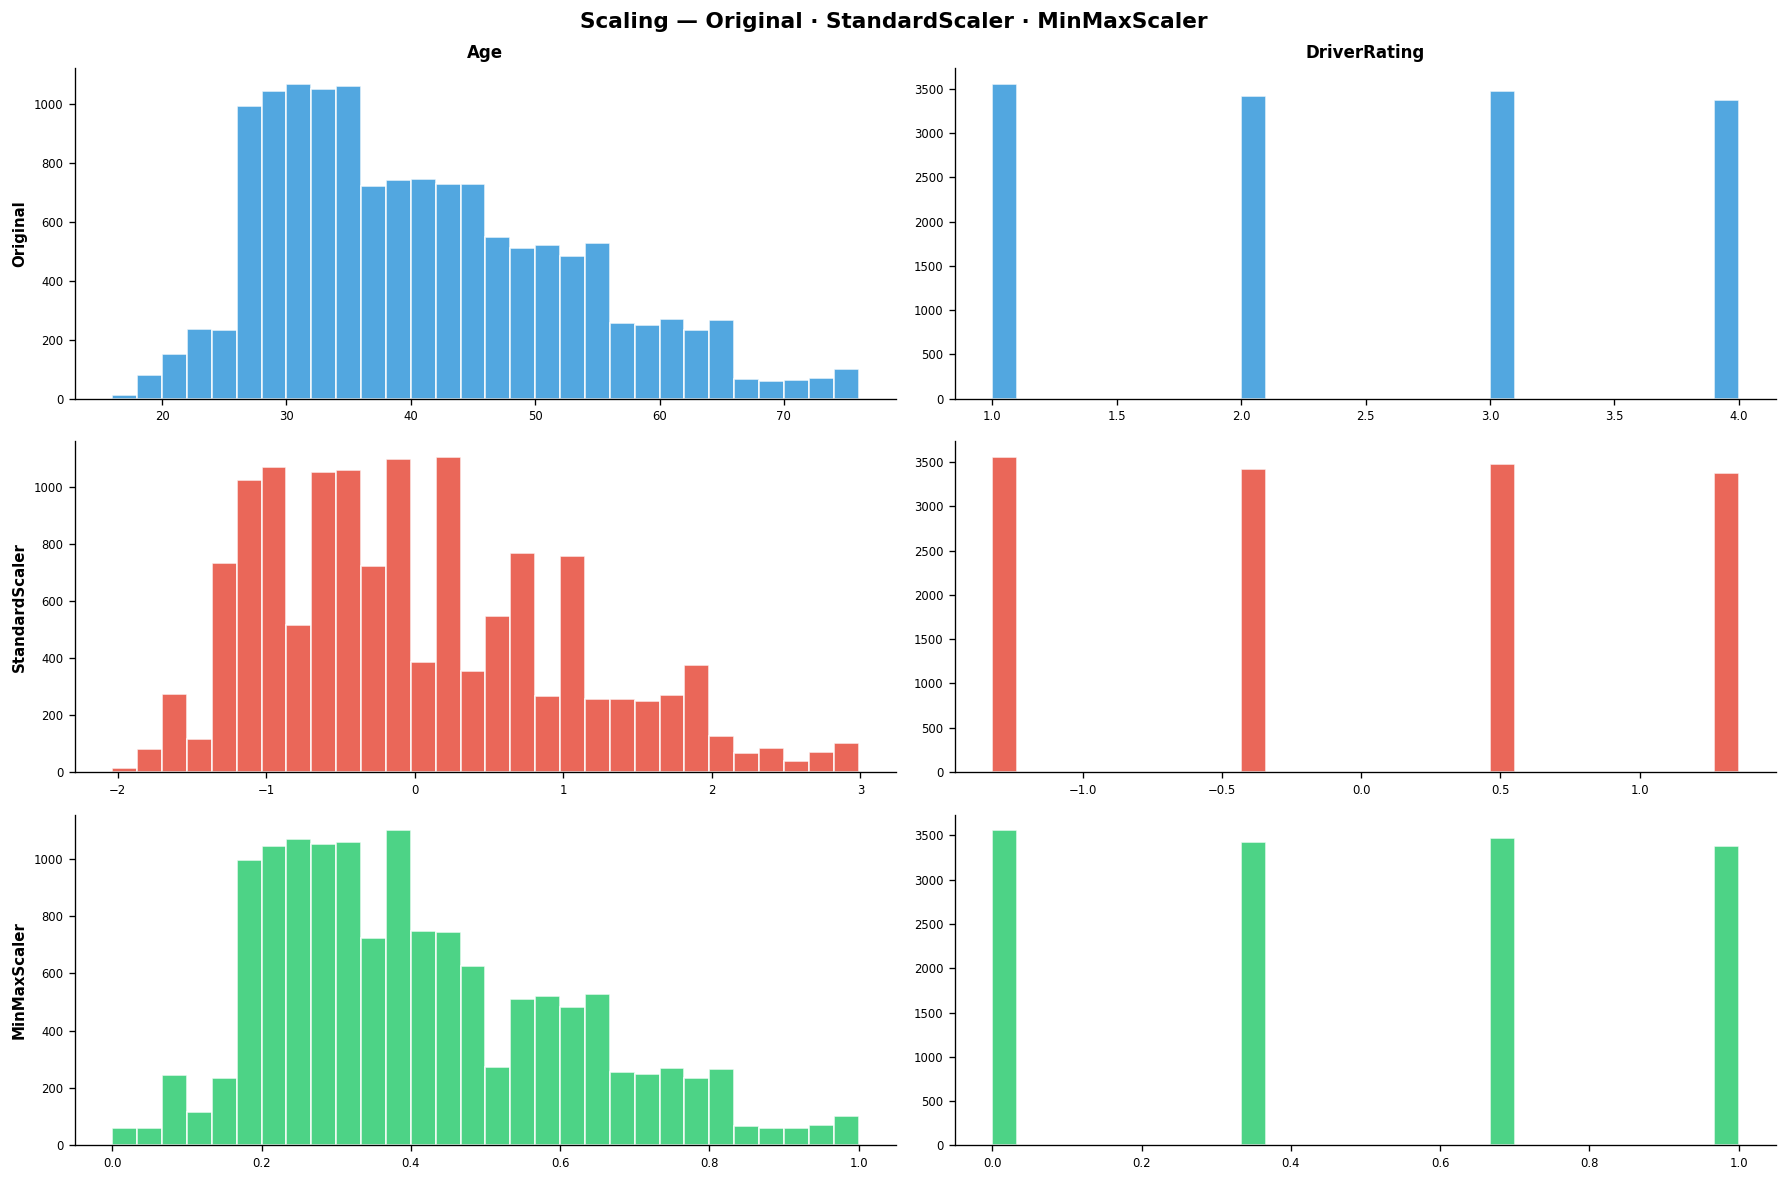

In [74]:
# Scaling Comparison: Original vs StandardScaler vs MinMaxScaler
scale_cols = [c for c in ['Age', 'Deductible', 'DriverRating'] if c in features.columns]

scaled_std = StandardScaler().fit_transform(features[scale_cols])
scaled_mm  = MinMaxScaler().fit_transform(features[scale_cols])

fig, axes = plt.subplots(3, len(scale_cols), figsize=(15, 10))
fig.suptitle('Scaling — Original · StandardScaler · MinMaxScaler',
    fontsize=13, fontweight='bold')

rows = [(features[scale_cols].values, 'Original','#3498DB'),(scaled_std,'StandardScaler', '#E74C3C'),(scaled_mm,'MinMaxScaler','#2ECC71'),]

for row, (data, title, color) in enumerate(rows):
    for j, col in enumerate(scale_cols):
        ax = axes[row, j]
        ax.hist(data[:, j], bins=30, color=color, edgecolor='white', alpha=0.85)
        if j == 0:
            ax.set_ylabel(title, fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(col, fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

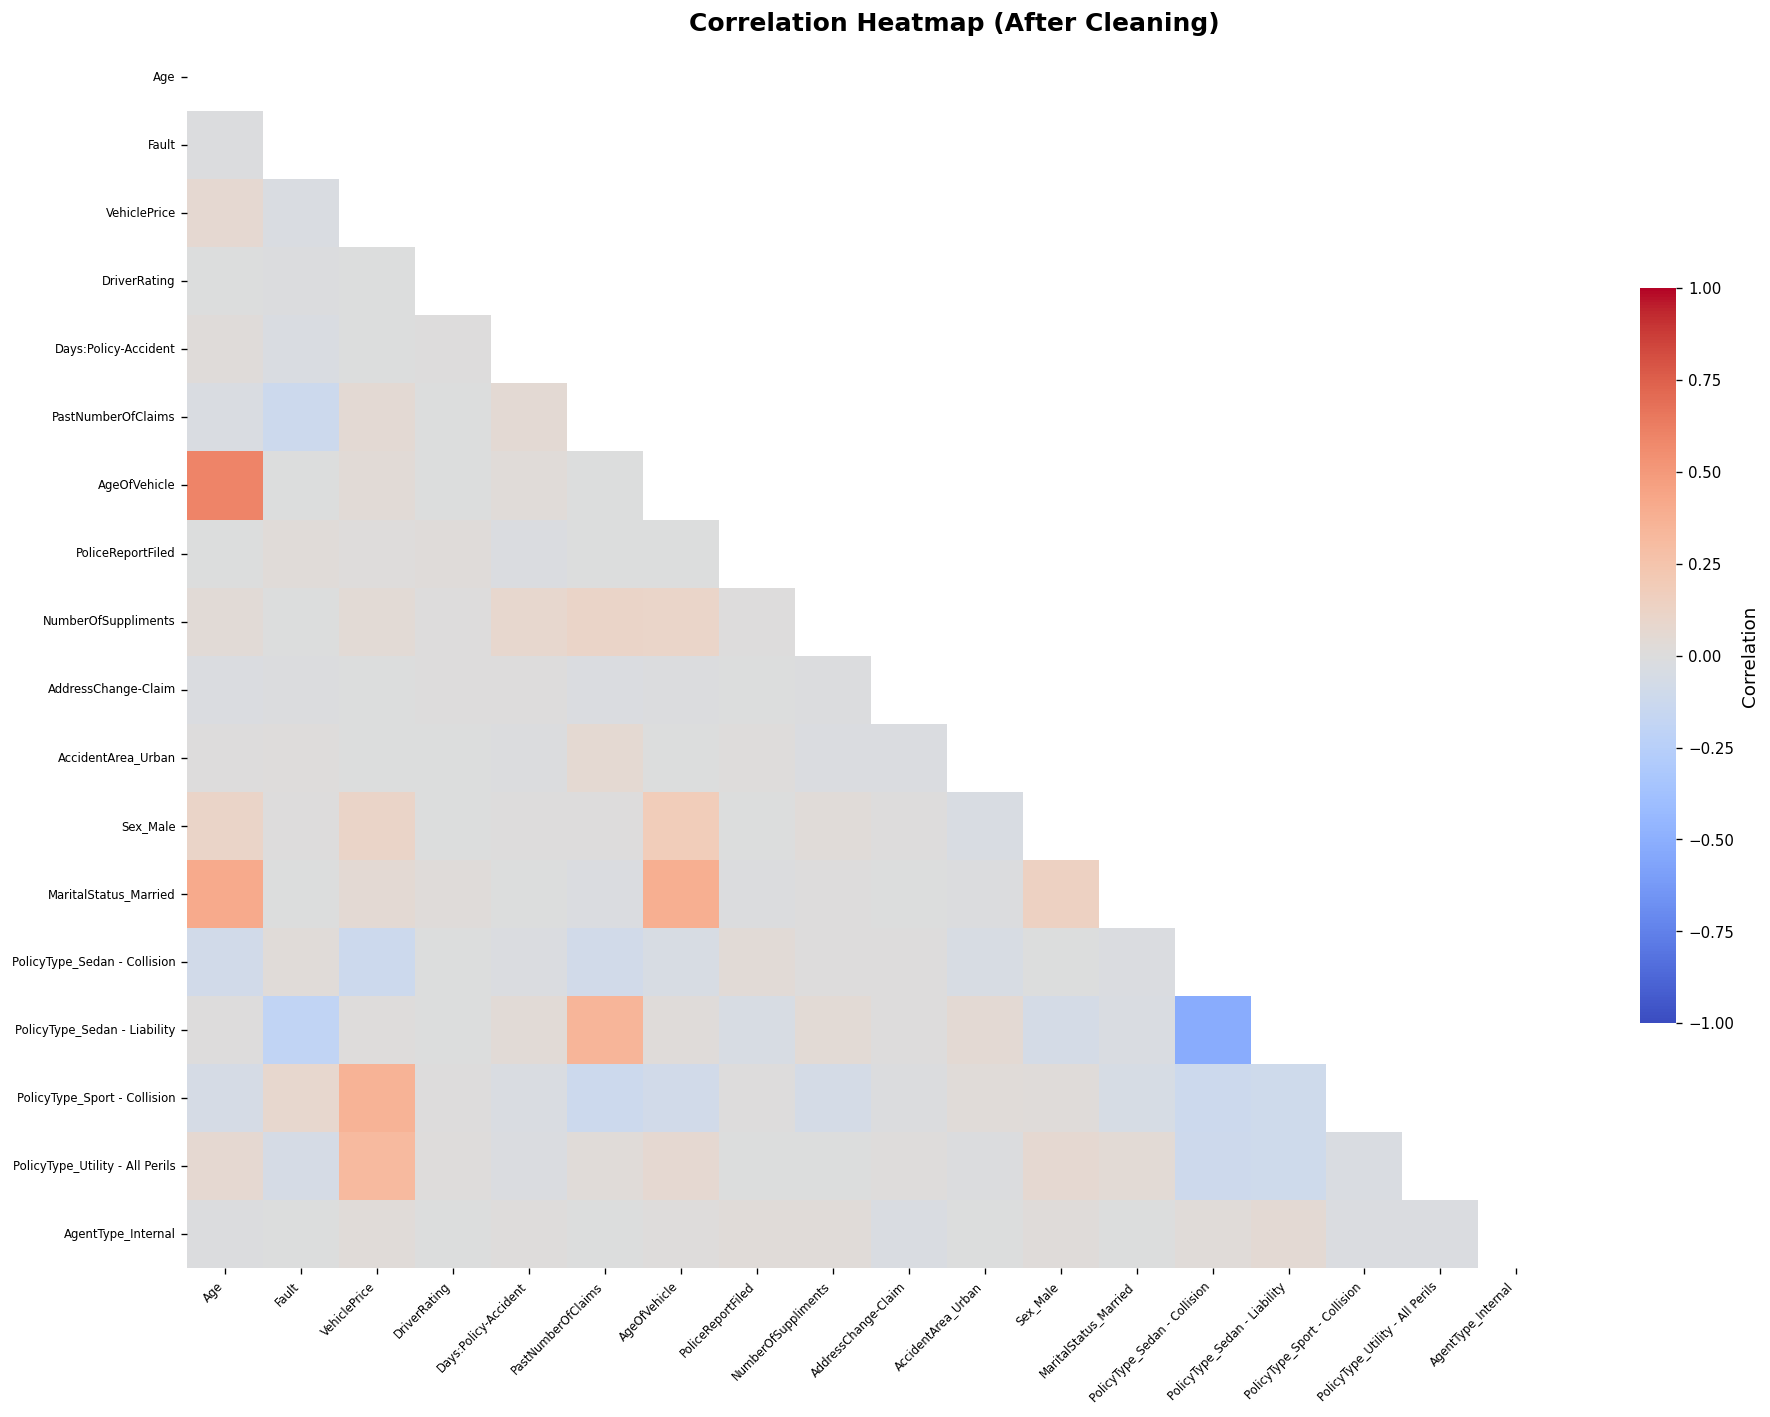

In [75]:
# Correlation Heatmap
corr_data = features.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_data, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
fig.suptitle('Correlation Heatmap (After Cleaning)', fontsize=15, fontweight='bold')
sns.heatmap(corr_data, mask=mask, ax=ax,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            cbar_kws=dict(shrink=0.6, label='Correlation'))
ax.tick_params(labelsize=7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  EPIC 4 — Model Building

### Activity 1.1 — Training Multiple Algorithms

Training set after SMOTE: (20824, 18)
Class counts after SMOTE: [10412 10412]
Test set shape: (2767, 18)


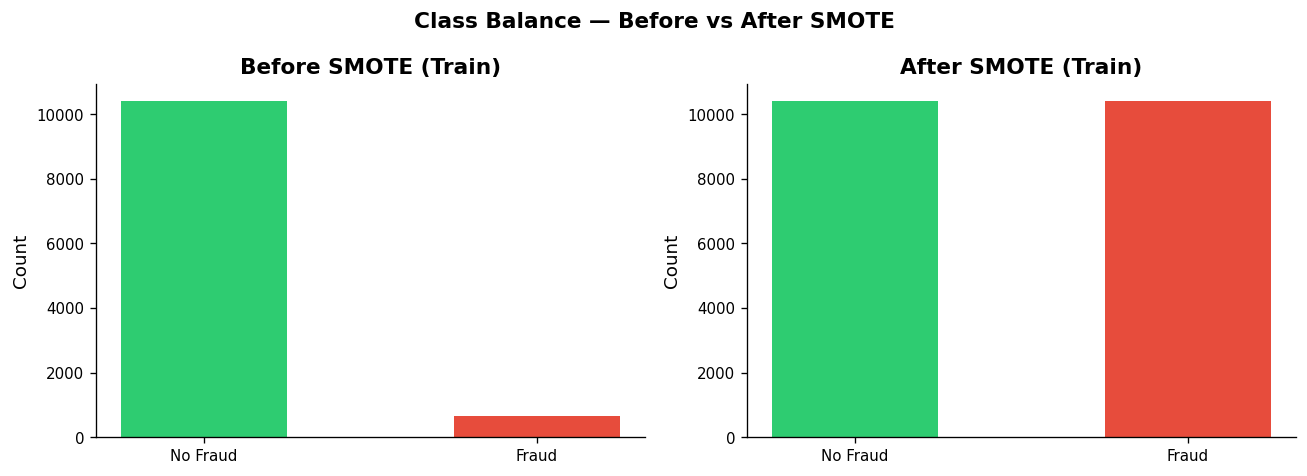

In [76]:
# Train/Test Split & SMOTE
X = features.values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Training set after SMOTE:', X_train_res.shape)
print('Class counts after SMOTE:', np.bincount(y_train_res))
print('Test set shape:',X_test.shape)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

# Class balance before vs after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Class Balance — Before vs After SMOTE', fontsize=13, fontweight='bold')
ax1.bar(['No Fraud','Fraud'], np.bincount(y_train), color=FRAUD_COLORS, width=0.5)
ax1.set_title('Before SMOTE (Train)'); ax1.set_ylabel('Count')
ax2.bar(['No Fraud','Fraud'], np.bincount(y_train_res), color=FRAUD_COLORS, width=0.5)
ax2.set_title('After SMOTE (Train)'); ax2.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Algorithm 1: Decision Tree

In [77]:
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_split=10,
                                   min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_sc, y_train_res)
y_pred_dt = dt_model.predict(X_test_sc)
y_prob_dt = dt_model.predict_proba(X_test_sc)[:, 1]
print(' Decision Tree ')
print(classification_report(y_test, y_pred_dt, target_names=['No Fraud','Fraud']))

 Decision Tree 
              precision    recall  f1-score   support

    No Fraud       0.98      0.68      0.80      2604
       Fraud       0.13      0.78      0.23       163

    accuracy                           0.68      2767
   macro avg       0.56      0.73      0.51      2767
weighted avg       0.93      0.68      0.77      2767



### Algorithm 2: Random Forest

In [78]:
rf_model = RandomForestClassifier(n_estimators=150, max_depth=10,
                                   min_samples_leaf=4, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train_res)
y_pred_rf = rf_model.predict(X_test_sc)
y_prob_rf  = rf_model.predict_proba(X_test_sc)[:, 1]
print(' Random Forest ')
print(classification_report(y_test, y_pred_rf, target_names=['No Fraud','Fraud']))

 Random Forest 
              precision    recall  f1-score   support

    No Fraud       0.98      0.72      0.83      2604
       Fraud       0.14      0.73      0.24       163

    accuracy                           0.72      2767
   macro avg       0.56      0.73      0.53      2767
weighted avg       0.93      0.72      0.79      2767



### Algorithm 3: K-Nearest Neighbours (KNN)

In [79]:
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_sc, y_train_res)
    k_scores.append(f1_score(y_test, knn.predict(X_test_sc)))

best_k = k_scores.index(max(k_scores)) + 1
print(f'Best K = {best_k}')

knn_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_model.fit(X_train_sc, y_train_res)
y_pred_knn = knn_model.predict(X_test_sc)
y_prob_knn = knn_model.predict_proba(X_test_sc)[:, 1]
print('KNN ')
print(classification_report(y_test, y_pred_knn, target_names=['No Fraud','Fraud']))

Best K = 7
KNN 
              precision    recall  f1-score   support

    No Fraud       0.97      0.79      0.87      2604
       Fraud       0.15      0.58      0.24       163

    accuracy                           0.78      2767
   macro avg       0.56      0.69      0.55      2767
weighted avg       0.92      0.78      0.83      2767



### Algorithm 4: Logistic Regression

In [80]:
lr_model = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
lr_model.fit(X_train_sc, y_train_res)
y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr  = lr_model.predict_proba(X_test_sc)[:, 1]
print(' Logistic Regression ')
print(classification_report(y_test, y_pred_lr, target_names=['No Fraud','Fraud']))

 Logistic Regression 
              precision    recall  f1-score   support

    No Fraud       0.98      0.72      0.83      2604
       Fraud       0.14      0.71      0.23       163

    accuracy                           0.72      2767
   macro avg       0.56      0.72      0.53      2767
weighted avg       0.93      0.72      0.79      2767



### Algorithm 5: Naïve Bayes

In [81]:
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train_res)
y_pred_nb = nb_model.predict(X_test_sc)
y_prob_nb  = nb_model.predict_proba(X_test_sc)[:, 1]
print(' Naive Bayes ')
print(classification_report(y_test, y_pred_nb, target_names=['No Fraud','Fraud']))
print('Class priors:', dict(zip(['No Fraud','Fraud'], nb_model.class_prior_.round(4))))

 Naive Bayes 
              precision    recall  f1-score   support

    No Fraud       0.99      0.62      0.76      2604
       Fraud       0.13      0.88      0.22       163

    accuracy                           0.64      2767
   macro avg       0.56      0.75      0.49      2767
weighted avg       0.94      0.64      0.73      2767

Class priors: {'No Fraud': np.float64(0.5), 'Fraud': np.float64(0.5)}


### Algorithm 6: Support Vector Machine (SVM)

In [82]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_sc, y_train_res)
y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm = svm_model.predict_proba(X_test_sc)[:, 1]
print('SVM (RBF kernel) ')
print(classification_report(y_test, y_pred_svm, target_names=['No Fraud','Fraud']))

SVM (RBF kernel) 
              precision    recall  f1-score   support

    No Fraud       0.97      0.74      0.84      2604
       Fraud       0.14      0.66      0.23       163

    accuracy                           0.73      2767
   macro avg       0.55      0.70      0.53      2767
weighted avg       0.92      0.73      0.80      2767



## ⚙️ EPIC 5 — Performance Testing & Hyperparameter Tuning

### Comparing All Trained Algorithms

In [83]:
all_models = {'Decision Tree':(y_pred_dt,  y_prob_dt),'Random Forest':(y_pred_rf,  y_prob_rf),'KNN':(y_pred_knn, y_prob_knn),'Logistic Regression': (y_pred_lr,  y_prob_lr),'Naive Bayes':(y_pred_nb,  y_prob_nb),'SVM':(y_pred_svm, y_prob_svm),}

results = {}
for name, (y_pred, y_prob) in all_models.items():
    results[name] = {'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),'Precision': round(precision_score(y_test, y_pred), 4),'Recall':    round(recall_score(y_test,    y_pred), 4),'F1 Score':  round(f1_score(y_test,        y_pred), 4),'ROC-AUC':   round(roc_auc_score(y_test,  y_prob), 4),}

results_df = pd.DataFrame(results).T.sort_values('Recall', ascending=False)
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Naive Bayes            0.6375     0.1270  0.8773    0.2219   0.7973
Decision Tree          0.6849     0.1319  0.7791    0.2256   0.8103
Random Forest          0.7210     0.1405  0.7301    0.2356   0.8197
Logistic Regression    0.7206     0.1378  0.7117    0.2308   0.8112
SVM                    0.7333     0.1365  0.6626    0.2264   0.7593
KNN                    0.7814     0.1492  0.5767    0.2371   0.7595


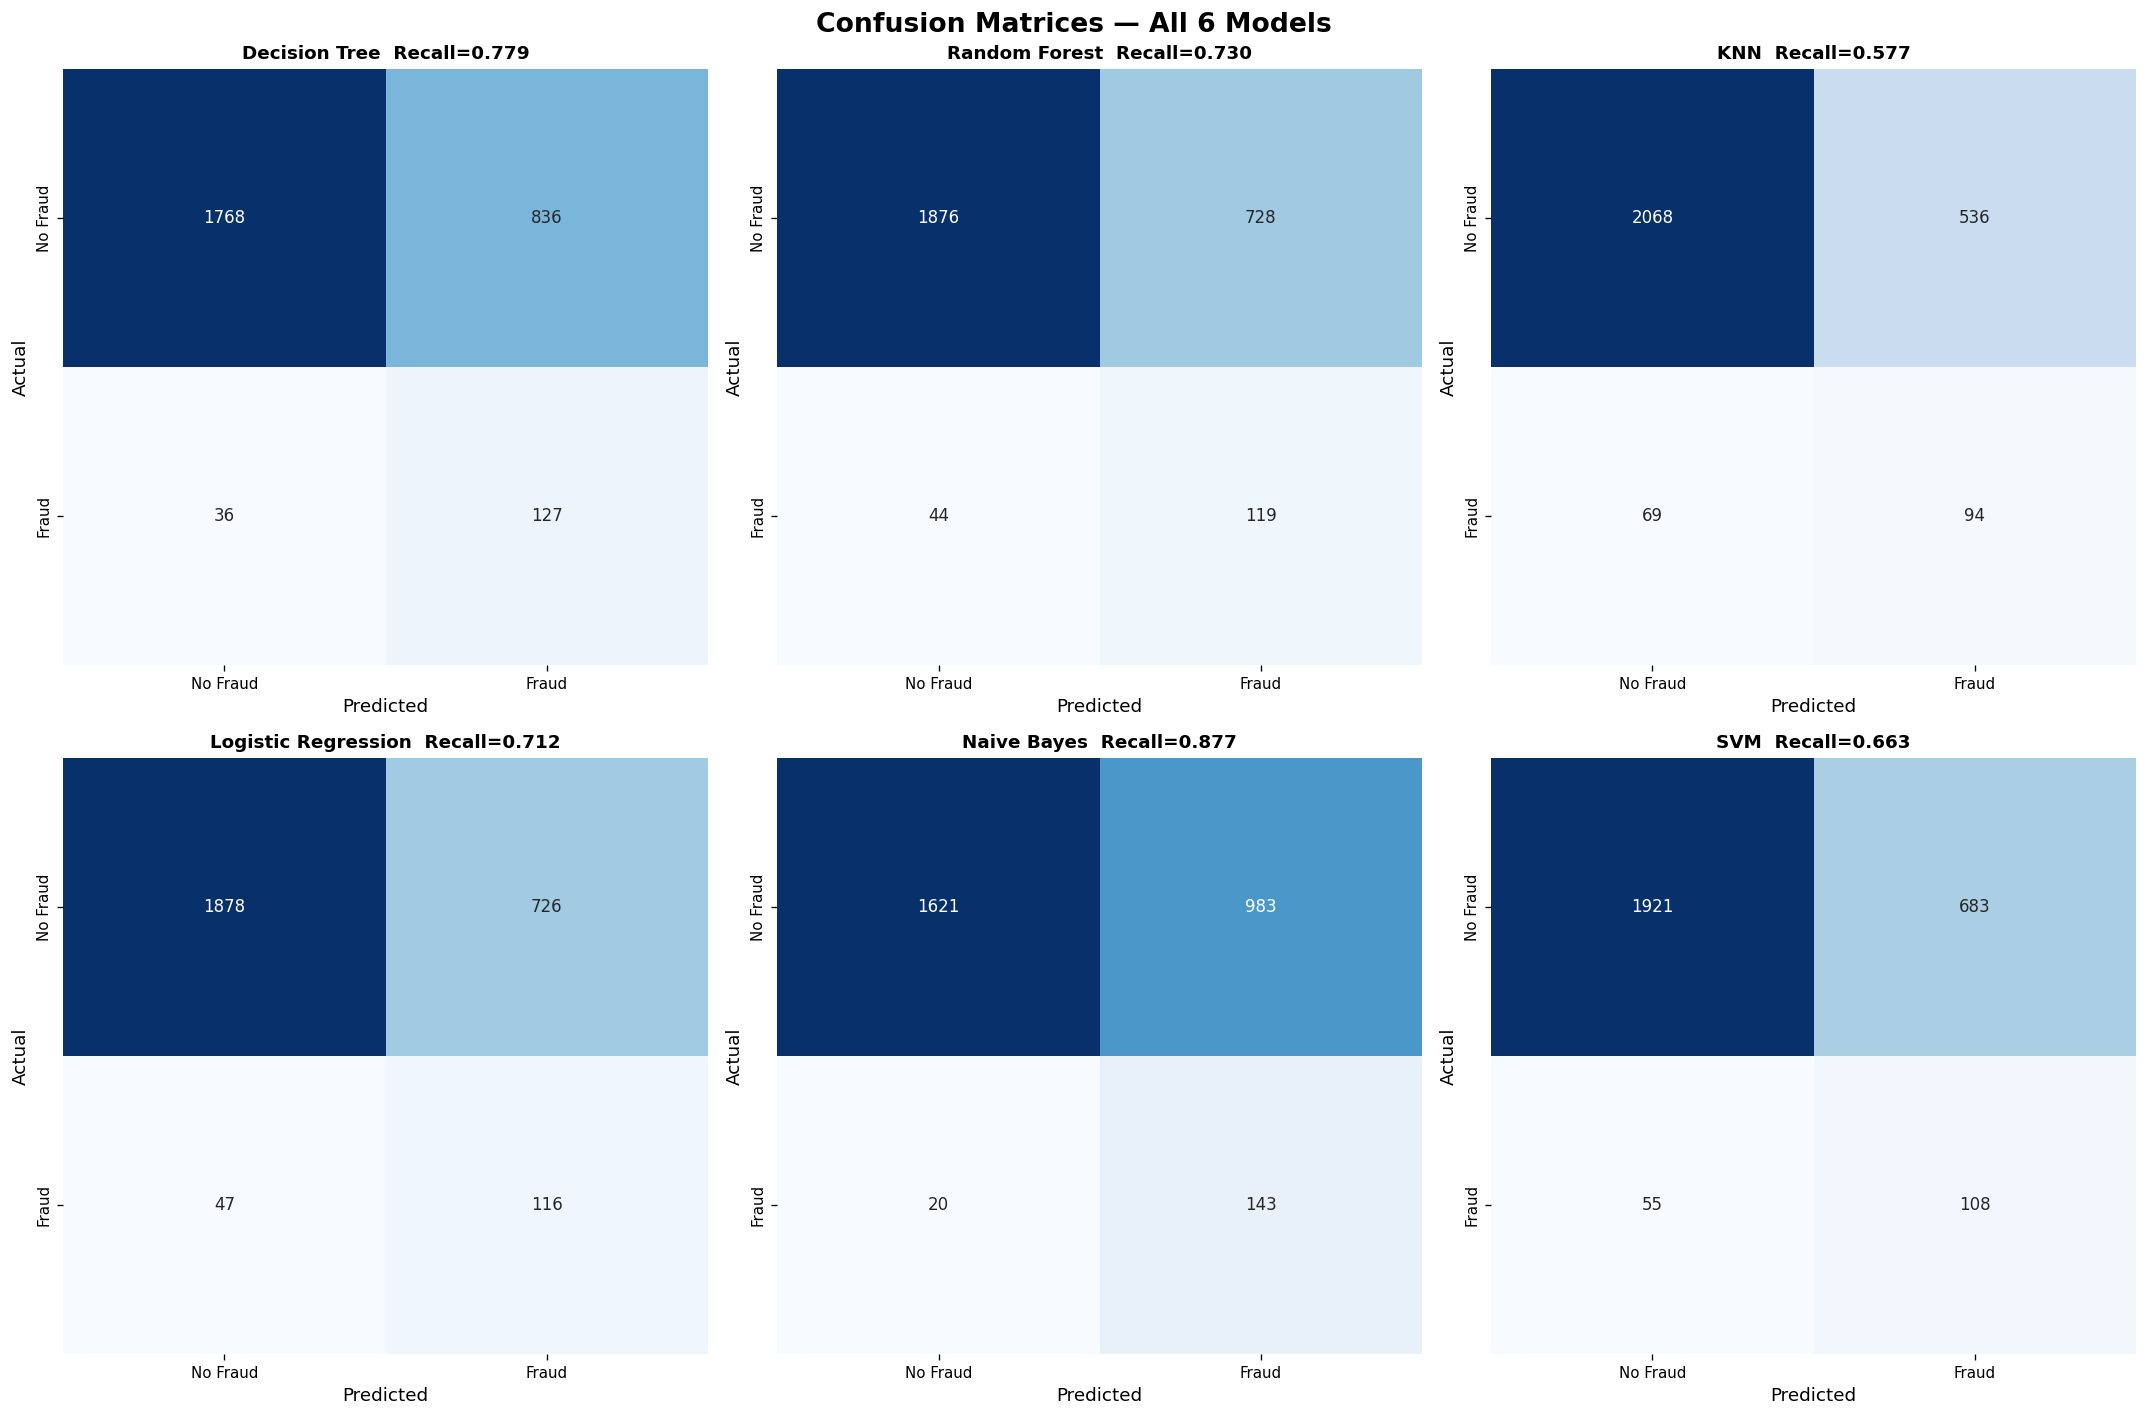

In [84]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices — All 6 Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (name, (y_pred, y_prob)) in enumerate(all_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Fraud','Fraud'],
                yticklabels=['No Fraud','Fraud'], cbar=False)
    ax.set_title(f'{name}  Recall={results[name]["Recall"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

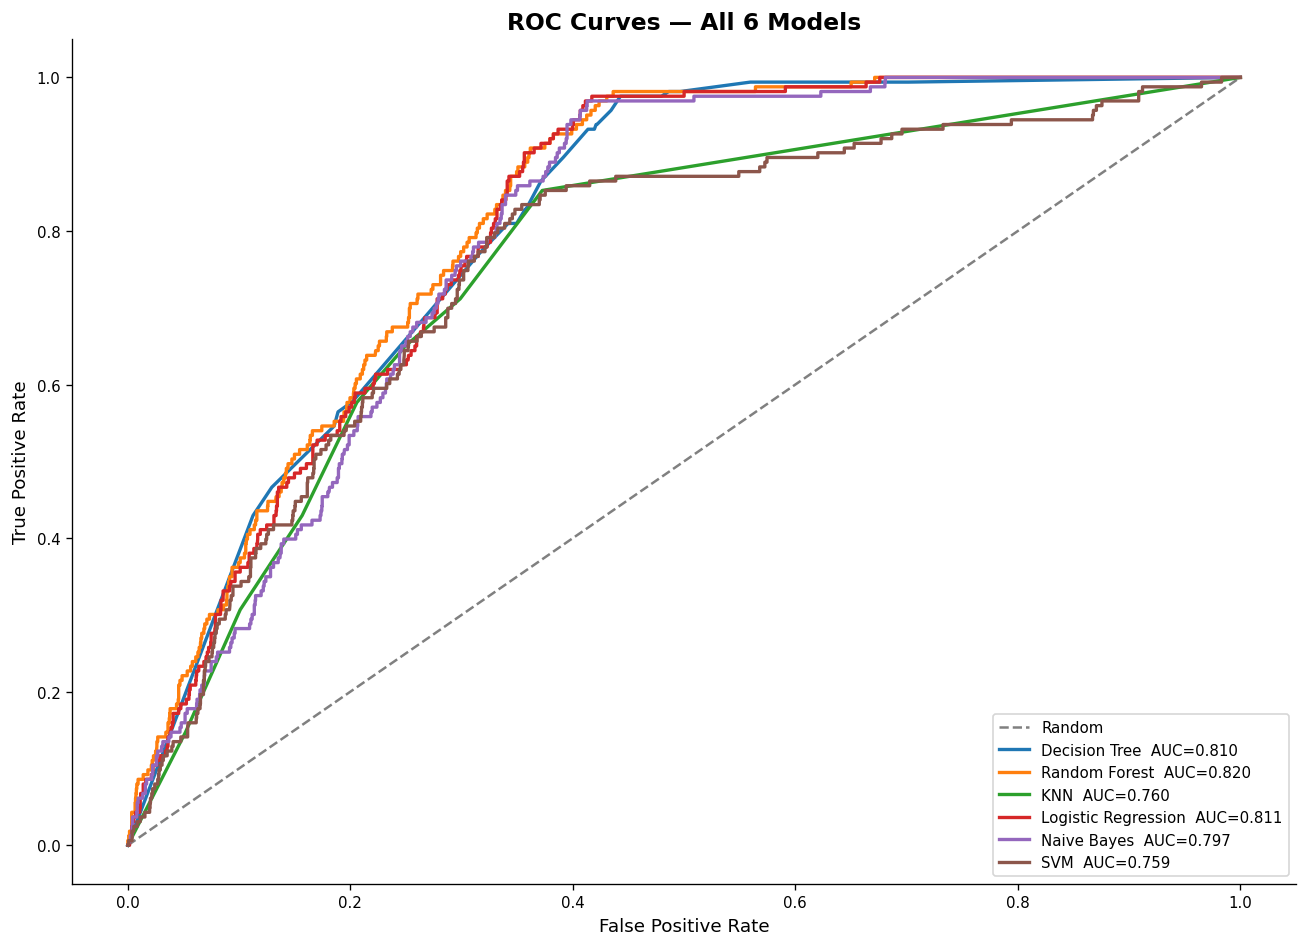

In [85]:
# ROC Curves
fig, ax = plt.subplots(figsize=(11, 8))
ax.plot([0,1],[0,1],'--', color='gray', label='Random')

for name, (y_pred, y_prob) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}  AUC={auc:.3f}')

ax.set_title('ROC Curves — All 6 Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

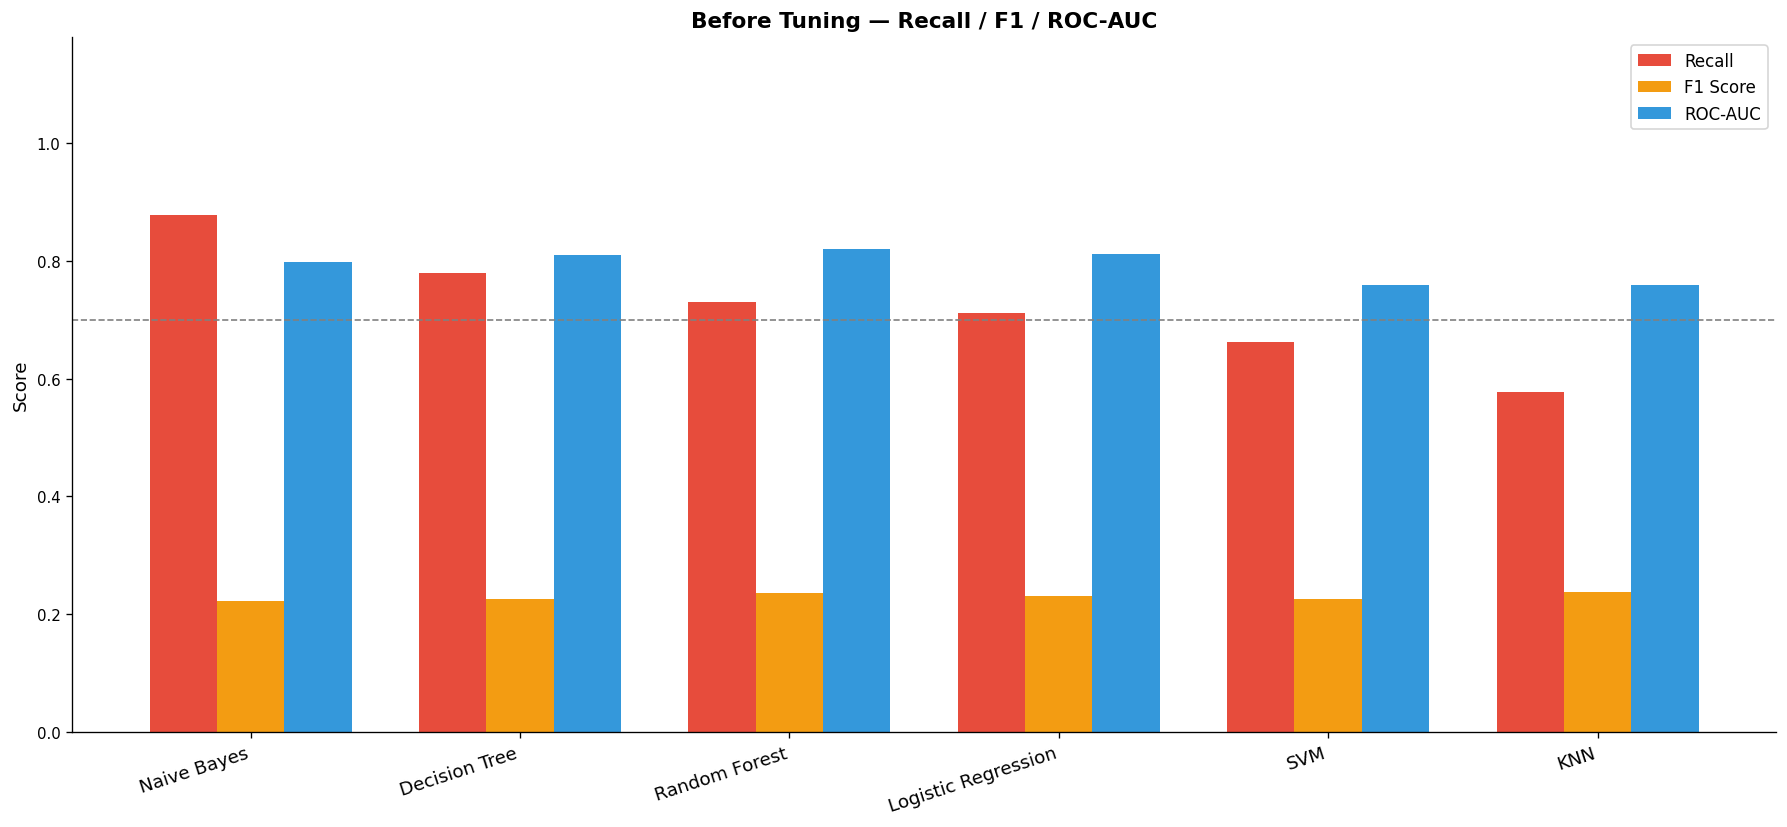

In [86]:
# Grouped bar : Recall / F1 / ROC-AUC (Before Tuning)
metrics  = ['Recall','F1 Score','ROC-AUC']
m_colors = ['#E74C3C','#F39C12','#3498DB']
m_names  = results_df.index.tolist()
x, width = np.arange(len(m_names)), 0.25

fig, ax = plt.subplots(figsize=(15, 7))
ax.set_title('Before Tuning — Recall / F1 / ROC-AUC', fontsize=13, fontweight='bold')

for j, (metric, color) in enumerate(zip(metrics, m_colors)):
    ax.bar(x + j*width, results_df[metric].values, width, label=metric, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(m_names, rotation=18, ha='right', fontsize=11)
ax.set_ylim(0, 1.18); ax.set_ylabel('Score')
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Activity 1.2 — Hyperparameter Tuning

In [88]:
# ── Tuning Decision Tree
print('Tuning Decision Tree...')
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth':[4,6,8], 'min_samples_split':[5,10],
     'min_samples_leaf':[2,5], 'criterion':['gini','entropy']},
    cv=3, scoring='recall', n_jobs=1)
dt_gs.fit(X_train_sc, y_train_res)
print(f'  Best: {dt_gs.best_params_} | Recall: {dt_gs.best_score_:.4f}')

# ── Tuning Random Forest
print('Tuning Random Forest...')
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators':[50,100], 'max_depth':[8,10]},
    cv=3, scoring='recall', n_jobs=1)
rf_gs.fit(X_train_sc, y_train_res)
print(f'  Best: {rf_gs.best_params_} | Recall: {rf_gs.best_score_:.4f}')

# ── Tuning Logistic Regression
print('Tuning Logistic Regression...')
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    {'C':[0.1,1.0,10.0], 'solver':['lbfgs','liblinear']},
    cv=3, scoring='recall', n_jobs=1)
lr_gs.fit(X_train_sc, y_train_res)
print(f'  Best: {lr_gs.best_params_} | Recall: {lr_gs.best_score_:.4f}')

print('All tuning complete.')

Tuning Decision Tree...
  Best: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5} | Recall: 0.9449
Tuning Random Forest...
  Best: {'max_depth': 8, 'n_estimators': 100} | Recall: 0.9654
Tuning Logistic Regression...
  Best: {'C': 0.1, 'solver': 'liblinear'} | Recall: 0.8936
All tuning complete.


In [94]:
#  Before vs After Comparison
tuned_models = {'Decision Tree':dt_gs.best_estimator_,'Random Forest':rf_gs.best_estimator_,'Logistic Regression': lr_gs.best_estimator_,}

before_after = []
for name, tuned in tuned_models.items():
    y_pred_before = all_models[name][0]
    y_pred_after  = tuned.predict(X_test_sc)
    before_after.append({
        'Model':name,'Recall Before': round(recall_score(y_test, y_pred_before), 4),'Recall After': round(recall_score(y_test, y_pred_after),  4),'F1 Before': round(f1_score(y_test, y_pred_before), 4),'F1 After': round(f1_score(y_test, y_pred_after),  4),})

ba_df = pd.DataFrame(before_after).set_index('Model')
print(ba_df.round(4).to_string())

                     Recall Before  Recall After  F1 Before  F1 After
Model                                                                
Decision Tree               0.7791        0.6994     0.2256    0.2231
Random Forest               0.7301        0.7791     0.2356    0.2345
Logistic Regression         0.7117        0.7055     0.2308    0.2284


In [95]:
#Final Leaderboard
all_res_tuned = dict(results)

for name, tuned in tuned_models.items():
    y_pred = tuned.predict(X_test_sc)
    y_prob = tuned.predict_proba(X_test_sc)[:, 1]
    all_res_tuned[name + ' (Tuned)'] = {'Accuracy': round(accuracy_score(y_test, y_pred), 4),'Recall':   round(recall_score(y_test,   y_pred), 4),'F1 Score': round(f1_score(y_test,y_pred), 4),'ROC-AUC':  round(roc_auc_score(y_test,  y_prob), 4),}

final_df = pd.DataFrame(all_res_tuned).T.sort_values('Recall', ascending=False)
print('FINAL LEADERBOARD ')
print(final_df.to_string())

FINAL LEADERBOARD 
                             Accuracy  Precision  Recall  F1 Score  ROC-AUC
Naive Bayes                    0.6375     0.1270  0.8773    0.2219   0.7973
Decision Tree                  0.6849     0.1319  0.7791    0.2256   0.8103
Random Forest (Tuned)          0.7004        NaN  0.7791    0.2345   0.8223
Random Forest                  0.7210     0.1405  0.7301    0.2356   0.8197
Logistic Regression            0.7206     0.1378  0.7117    0.2308   0.8112
Logistic Regression (Tuned)    0.7192        NaN  0.7055    0.2284   0.8110
Decision Tree (Tuned)          0.7130        NaN  0.6994    0.2231   0.7882
SVM                            0.7333     0.1365  0.6626    0.2264   0.7593
KNN                            0.7814     0.1492  0.5767    0.2371   0.7595


##  Save Best Model

In [96]:
best_name = final_df['Recall'].idxmax()
print(f'Best model: {best_name}')

model_map = {'Decision Tree':dt_model,'Decision Tree (Tuned)':dt_gs.best_estimator_,'Random Forest':rf_model,'Random Forest (Tuned)':rf_gs.best_estimator_,'KNN':knn_model,'Logistic Regression':lr_model,'Logistic Regression (Tuned)': lr_gs.best_estimator_,'Naive Bayes':nb_model,'SVM':svm_model,}

best_model = model_map.get(best_name, rf_model)

os.makedirs('deployment', exist_ok=True)

with open('deployment/fraud_model.pkl','wb') as f: pickle.dump(best_model,f)
with open('deployment/scaler.pkl','wb') as f: pickle.dump(scaler,f)
with open('deployment/feature_cols.pkl','wb') as f: pickle.dump(list(features.columns),f)

print('Saved: deployment/fraud_model.pkl  — trained model')
print('Saved: deployment/scaler.pkl  — feature scaler')
print('Saved: deployment/feature_cols.pkl   — feature column list')

Best model: Naive Bayes
Saved: deployment/fraud_model.pkl  — trained model
Saved: deployment/scaler.pkl  — feature scaler
Saved: deployment/feature_cols.pkl   — feature column list
